# LangGraph 入门教程

[大语言模型 (LLMs)](https://python.langchain.com/docs/concepts/chat_models/) 使得将智能嵌入到新一类应用程序中成为可能。[LangGraph](https://langchain-ai.github.io/langgraph/) 是一个帮助构建使用 LLM 的应用程序的框架。在这里，我们将概述 LangGraph 的基础知识，解释其优势，展示如何使用它来构建工作流程/智能体，以及它如何与 [LangChain](https://www.langchain.com/) / [LangSmith](https://docs.smith.langchain.com/) 配合使用。

![ecosystem](./img/ecosystem.png)

## 聊天模型

[聊天模型](https://python.langchain.com/docs/concepts/chat_models/) 是 LLM 应用程序的基础。它们通常通过聊天界面访问，该界面将[消息](https://python.langchain.com/docs/concepts/messages/)列表作为输入并返回一条[消息](https://python.langchain.com/docs/concepts/messages/)作为输出。LangChain 为聊天模型提供了[标准化接口](https://python.langchain.com/api_reference/langchain/chat_models/langchain.chat_models.base.init_chat_model.html)，使得[访问许多不同的提供商](https://python.langchain.com/docs/integrations/chat/)变得容易。

In [1]:
import sys
import os
sys.path.append(os.path.abspath('..'))

from dotenv import load_dotenv
load_dotenv("../.env", override=True)

True

In [2]:
from langchain.chat_models import init_chat_model
llm = init_chat_model("openai:gpt-4.1", temperature=0)

## 运行模型

`init_chat_model` 接口提供了使用聊天模型的[标准化](https://python.langchain.com/docs/concepts/runnables/)方法，包括：
- `invoke()`：单个输入被转换为输出。
- `stream()`：输出在生成时进行[流式传输](https://python.langchain.com/docs/concepts/streaming/#stream-and-astream)。

In [3]:
# result = llm.invoke("什么是智能体？")

In [4]:
# type(result)

In [5]:
from rich.markdown import Markdown
# Markdown(result.content)

## 工具

[工具](https://python.langchain.com/docs/concepts/tools/) 是可以被聊天模型调用的实用程序。在 LangChain 中，可以使用 `@tool` 装饰器创建工具，它将 Python 函数转换为可调用的工具。它会自动从函数定义中推断工具的名称、描述和预期参数。您也可以使用 [模型上下文协议 (MCP) 服务器](https://github.com/langchain-ai/langchain-mcp-adapters) 作为 LangChain 兼容的工具。

In [6]:
from langchain.tools import tool

@tool
def write_email(to: str, subject: str, content: str) -> str:
    """撰写并发送电子邮件。"""
    # 占位符响应 - 在真实应用中会发送电子邮件
    return f"电子邮件已发送至 {to}，主题为 '{subject}'，内容为：{content}"

In [7]:
type(write_email)

langchain_core.tools.structured.StructuredTool

In [8]:
write_email.args

{'to': {'title': 'To', 'type': 'string'},
 'subject': {'title': 'Subject', 'type': 'string'},
 'content': {'title': 'Content', 'type': 'string'}}

In [9]:
Markdown(write_email.description)

撰写并发送电子邮件。

## 工具调用

工具可以被 LLM [调用](https://python.langchain.com/docs/concepts/tool_calling/)。当工具绑定到模型时，模型可以选择通过返回带有工具参数的结构化输出来调用工具。我们使用 `bind_tools` 方法来为 LLM 增强工具。

![tool-img](img/tool_call_detail.png)

提供商通常有 [如 `tool_choice` 的参数](https://python.langchain.com/docs/how_to/tool_choice/) 来强制调用特定工具。`any` 将选择至少一个工具。

此外，我们可以 [设置 `parallel_tool_calls=False`](https://python.langchain.com/docs/how_to/tool_calling_parallel/) 来确保模型一次只会调用一个工具。

In [10]:
# 将工具连接到聊天模型
model_with_tools = llm.bind_tools([write_email], tool_choice="any", parallel_tool_calls=False)

# 模型现在能够调用工具
output = model_with_tools.invoke("为我老板 (boss@company.ai) 起草一封关于明天会议的回复")

In [11]:
type(output)

langchain_core.messages.ai.AIMessage

In [12]:
output

AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_NloCoBuxb6d8K87o2cwpIezZ', 'function': {'arguments': '{"to":"boss@company.ai","subject":"Re: 关于明天会议的回复","content":"尊敬的老板：\\n\\n感谢您的来信。关于明天的会议，我已收到通知，并会准时参加。如有需要提前准备的材料或议题，请随时告知。\\n\\n祝好！\\n\\n[您的姓名]"}', 'name': 'write_email'}, 'type': 'function'}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 86, 'prompt_tokens': 72, 'total_tokens': 158, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4.1-2025-04-14', 'system_fingerprint': 'fp_daf5fcc80a', 'id': 'chatcmpl-CIWdQzaPibwAI22wU2VvlFF1wsRiX', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--c3686add-a655-4bfd-a65d-f142eb697501-0', tool_calls=[{'name': 'write_email', 'args': {'to': 'boss@company.ai', 'subject': 'Re: 关于明天会议的回复', 'content

In [13]:
# 提取工具调用并执行它们
args = output.tool_calls[0]['args']
args

{'to': 'boss@company.ai',
 'subject': 'Re: 关于明天会议的回复',
 'content': '尊敬的老板：\n\n感谢您的来信。关于明天的会议，我已收到通知，并会准时参加。如有需要提前准备的材料或议题，请随时告知。\n\n祝好！\n\n[您的姓名]'}

In [14]:
# 调用工具
result = write_email.invoke(args)
Markdown(result)

电子邮件已发送至 boss@company.ai，主题为 'Re: 关于明天会议的回复'，内容为：尊敬的老板：                            

感谢您的来信。关于明天的会议，我已收到通知，并会准时参加。如有需要提前准备的材料或议题，请随时告知。               

祝好！                                                                                                             

[您的姓名]

![basic_prompt](img/tool_call.png)

## 工作流
 
使用 LLM 构建应用程序有许多模式。

[我们可以将 LLM 调用嵌入到预定义的工作流中](https://langchain-ai.github.io/langgraph/tutorials/workflows/)，让系统有更多自主权来做决策。

例如，我们可以添加一个路由步骤来确定是否要写电子邮件。

![workflow_example](img/workflow_example.png)

## 智能体

我们可以进一步增加自主权，允许 LLM 动态指导其自己的工具使用。

[智能体](https://langchain-ai.github.io/langgraph/tutorials/workflows/#agent) 通常实现为循环中的工具调用，其中每个工具调用的输出用于指导下一个动作。

![agent_example](img/agent_example.png)

智能体非常适合开放性问题，在这些问题中很难提前预测 *确切* 需要的步骤。
 
当控制流可以提前轻松定义时，工作流往往是合适的。

![workflow_v_agent](img/workflow_v_agent.png)

## 什么是 LangGraph？

[LangGraph](https://langchain-ai.github.io/langgraph/concepts/high_level/) 提供了位于 *任何* 工作流或智能体下方的低级支持基础设施。

它不抽象提示或架构，并提供了一些好处：

- **控制**：使定义和/或组合智能体和工作流变得容易。
- **持久性**：提供一种持久化图状态的方法，这既支持内存又支持人工干预。
- **测试、调试和部署**：为测试、调试和部署应用程序提供简单的上手路径。

### 控制

LangGraph 让您将应用程序定义为一个图，包含：

1. *状态*：在应用程序过程中我们需要跟踪什么信息？
2. *节点*：在应用程序过程中我们想如何更新这些信息？
3. *边*：我们想如何将这些节点连接在一起？

我们可以使用 [`StateGraph` 类](https://langchain-ai.github.io/langgraph/concepts/low_level/#graphs) 来初始化一个带有 [`State` 对象](https://langchain-ai.github.io/langgraph/concepts/low_level/#state) 的 LangGraph 图。

`State` 定义了我们想要在应用程序过程中跟踪的信息的模式。

这可以是 Python 中任何具有 `getattr()` 的对象，例如字典、数据类或 Pydantic 对象：

- TypeDict 最快但不支持默认值
- Dataclass 基本上一样快，支持点语法 `state.foo`，并有默认值。
- Pydantic 较慢（特别是带有自定义验证器的）但提供类型验证。

In [15]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

class StateSchema(TypedDict):
    request: str
    email: str

workflow = StateGraph(StateSchema)

每个节点只是一个 Python 函数或 TypeScript 代码。这给了我们对每个节点内部逻辑的完全控制。

它们接收当前状态，并返回一个字典来更新状态。

默认情况下，[状态键会被覆盖](https://langchain-ai.github.io/langgraph/how-tos/state-reducers/)。

但是，您可以 [定义自定义更新逻辑](https://langchain-ai.github.io/langgraph/concepts/low_level/#reducers)。

![nodes_edges](img/nodes_edges.png)

In [16]:
def write_email_node(state: StateSchema) -> StateSchema:
    # 处理请求的命令式代码
    output = model_with_tools.invoke(state["request"])
    args = output.tool_calls[0]['args']
    email = write_email.invoke(args)
    return {"email": email}

边将节点连接在一起。

我们通过向状态图添加边和节点来指定控制流。

In [17]:
workflow = StateGraph(StateSchema)
workflow.add_node("write_email_node", write_email_node)
workflow.add_edge(START, "write_email_node")
workflow.add_edge("write_email_node", END)

app = workflow.compile()

In [18]:
app.invoke({"request": "为我老板 (boss@company.ai) 起草一封关于明天会议的回复"})

{'request': '为我老板 (boss@company.ai) 起草一封关于明天会议的回复',
 'email': "电子邮件已发送至 boss@company.ai，主题为 'Re: 关于明天会议的回复'，内容为：尊敬的老板：\n\n感谢您的来信。关于明天的会议，我已收到通知，并会准时参加。如有需要提前准备的材料或需要关注的议题，请随时告知。\n\n期待与您的交流。\n\n祝好！\n\n[您的姓名]"}

节点之间的路由可以使用简单函数 [有条件地](https://langchain-ai.github.io/langgraph/concepts/low_level/#conditional-edges) 完成。

此函数的返回值用作要将状态发送到的下一个节点（或节点列表）的名称。

您可以选择提供一个字典，将 `should_continue` 输出映射到下一个节点的名称。

In [19]:
from typing import Literal
from langgraph.graph import MessagesState
import sys
import os
sys.path.append('../src')
from email_assistant.utils import show_graph

def call_llm(state: MessagesState) -> MessagesState:
    """运行 LLM"""

    output = model_with_tools.invoke(state["messages"])
    return {"messages": [output]}

def run_tool(state: MessagesState):
    """执行工具调用"""

    result = []
    for tool_call in state["messages"][-1].tool_calls:
        observation = write_email.invoke(tool_call["args"])
        result.append({"role": "tool", "content": observation, "tool_call_id": tool_call["id"]})
    return {"messages": result}

def should_continue(state: MessagesState) -> Literal["run_tool", "__end__"]:
    """路由到工具处理器，或如果调用了 Done 工具则结束"""
    
    # 获取最后一条消息
    messages = state["messages"]
    last_message = messages[-1]
    
    # 如果最后一条消息是工具调用，检查是否是 Done 工具调用
    if last_message.tool_calls:
        return "run_tool"
    # 否则，我们停止（回复用户）
    return END

workflow = StateGraph(MessagesState)
workflow.add_node("call_llm", call_llm)
workflow.add_node("run_tool", run_tool)
workflow.add_edge(START, "call_llm")
workflow.add_conditional_edges("call_llm", should_continue, {"run_tool": "run_tool", END: END})
workflow.add_edge("run_tool", END)

# 运行工作流
app = workflow.compile()

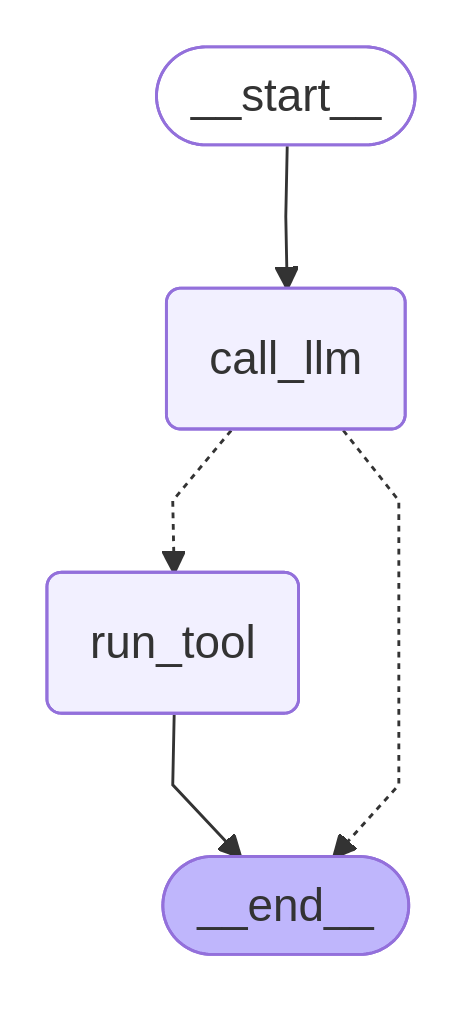

In [20]:
show_graph(app)

In [21]:
result = app.invoke({"messages": [{"role": "user", "content": "为我老板 (boss@company.ai) 起草一封回复，确认我想参加 Interrupt！"}]})
for m in result["messages"]:
    m.pretty_print()

================================ Human Message =================================

为我老板 (boss@company.ai) 起草一封回复，确认我想参加 Interrupt！
================================== Ai Message ==================================
Tool Calls:
  write_email (call_MMppcf8QsZ3pcizdqRtJduqj)
 Call ID: call_MMppcf8QsZ3pcizdqRtJduqj
  Args:
    to: boss@company.ai
    subject: Re: Interrupt 会议参与确认
    content: 您好，

感谢您的邀请。我确认希望参加 Interrupt！会议，并期待能从中获得新的见解和收获。

如有进一步的安排或需要我提前准备的事项，请随时告知。

谢谢！

[您的名字]
================================= Tool Message =================================

电子邮件已发送至 boss@company.ai，主题为 'Re: Interrupt 会议参与确认'，内容为：您好，

感谢您的邀请。我确认希望参加 Interrupt！会议，并期待能从中获得新的见解和收获。

如有进一步的安排或需要我提前准备的事项，请随时告知。

谢谢！

[您的名字]


使用这些低级组件，您可以构建许多不同的工作流和智能体。请参见 [此教程](https://langchain-ai.github.io/langgraph/tutorials/workflows/)！

因为智能体是如此常见的模式，[LangGraph](https://langchain-ai.github.io/langgraph/tutorials/workflows/#pre-built) 有 [预构建的智能体](https://langchain-ai.github.io/langgraph/agents/overview/?ref=blog.langchain.dev#what-is-an-agent) 抽象。

使用 LangGraph 的 [预构建方法](https://langchain-ai.github.io/langgraph/tutorials/workflows/#pre-built)，我们只需传入 LLM、工具和提示。

In [22]:
from langgraph.prebuilt import create_react_agent

agent = create_react_agent(
    model=llm,
    tools=[write_email],
    prompt="使用提供的工具响应用户的请求。"  
)

# 运行智能体
result = agent.invoke(
    {"messages": [{"role": "user", "content": "为我老板 (boss@company.ai) 起草一封回复，确认我想参加 Interrupt！"}]}
)

for m in result["messages"]:
    m.pretty_print()

================================ Human Message =================================

为我老板 (boss@company.ai) 起草一封回复，确认我想参加 Interrupt！
================================== Ai Message ==================================
Tool Calls:
  write_email (call_mZutsjPjoTDQdquBhxR9cs0P)
 Call ID: call_mZutsjPjoTDQdquBhxR9cs0P
  Args:
    to: boss@company.ai
    subject: Re: Interrupt 会议参与确认
    content: 尊敬的老板，

感谢您的邀请。我确认我想参加 Interrupt！期待在会议中与大家交流。

如有需要我提前准备的事项，请随时告知。

谢谢！

[您的名字]
================================= Tool Message =================================
Name: write_email

电子邮件已发送至 boss@company.ai，主题为 'Re: Interrupt 会议参与确认'，内容为：尊敬的老板，

感谢您的邀请。我确认我想参加 Interrupt！期待在会议中与大家交流。

如有需要我提前准备的事项，请随时告知。

谢谢！

[您的名字]
================================== Ai Message ==================================

邮件已为您起草并发送，内容确认您想参加 Interrupt。如果需要进一步修改或补充，请随时告知！


### 持久性

#### 线程

允许智能体在长时间运行的任务期间暂停可能非常有用。

LangGraph 有一个内置的持久性层，通过检查点实现，来启用这一功能。

当您使用检查点编译图时，检查点会在每一步保存图状态的 [检查点](https://langchain-ai.github.io/langgraph/concepts/persistence/#checkpoints)。

检查点保存到线程中，在图执行完成后可以访问。

![checkpointer](img/checkpoints.png)

我们使用 [检查点](https://langchain-ai.github.io/langgraph/concepts/persistence/#checkpointer-libraries) 编译图。

In [28]:
from langgraph.checkpoint.memory import MemorySaver as InMemorySaver

agent = create_react_agent(
    model=llm,
    tools=[write_email],
    prompt="使用提供的工具响应用户的请求。",
    checkpointer=InMemorySaver()
)

config = {"configurable": {"thread_id": "1"}}
result = agent.invoke({"messages": [{"role": "user", "content": "撰写电子邮件的好做法有哪些？"}]}, config)

In [29]:
# 获取最新状态快照
config = {"configurable": {"thread_id": "1"}}
state = agent.get_state(config)
for message in state.values['messages']:
    message.pretty_print()

================================ Human Message =================================

撰写电子邮件的好做法有哪些？
================================== Ai Message ==================================

撰写电子邮件时，有以下一些好做法可以帮助你更高效、专业地传达信息：

1. **明确主题**：邮件主题要简洁明了，能让收件人一眼看出邮件内容的核心。

2. **称呼得当**：根据收件人的身份和关系，使用合适的称呼，如“尊敬的张先生”、“亲爱的李老师”等。

3. **开门见山**：开头简要说明写信目的，让收件人快速了解你的诉求或意图。

4. **内容简洁有条理**：正文要分段，条理清晰，避免冗长和重复。可以使用项目符号或编号列出要点。

5. **礼貌用语**：注意语气礼貌，适当使用“请”、“谢谢”、“麻烦您”等表达尊重和感谢。

6. **结尾得体**：用合适的结尾语，如“祝好”、“顺祝商祺”等，并署上自己的姓名和联系方式。

7. **检查语法和拼写**：发送前仔细检查邮件内容，避免错别字和语法错误。

8. **附件说明**：如有附件，正文中要注明，并确保附件已正确添加。

9. **避免群发泄露**：群发邮件时，使用“密送（BCC）”保护收件人隐私。

10. **及时回复**：收到邮件后应及时回复，展现你的专业和重视。

这些好做法有助于提升邮件的专业性和沟通效率。


In [30]:
# 继续对话
result = agent.invoke({"messages": [{"role": "user", "content": "好的，让我们使用第3条建议来为我老板起草一封回复，确认我想参加 Interrupt"}]}, config)
for m in result['messages']:
    m.pretty_print()

================================ Human Message =================================

撰写电子邮件的好做法有哪些？
================================== Ai Message ==================================

撰写电子邮件时，有以下一些好做法可以帮助你更高效、专业地传达信息：

1. **明确主题**：邮件主题要简洁明了，能让收件人一眼看出邮件内容的核心。

2. **称呼得当**：根据收件人的身份和关系，使用合适的称呼，如“尊敬的张先生”、“亲爱的李老师”等。

3. **开门见山**：开头简要说明写信目的，让收件人快速了解你的诉求或意图。

4. **内容简洁有条理**：正文要分段，条理清晰，避免冗长和重复。可以使用项目符号或编号列出要点。

5. **礼貌用语**：注意语气礼貌，适当使用“请”、“谢谢”、“麻烦您”等表达尊重和感谢。

6. **结尾得体**：用合适的结尾语，如“祝好”、“顺祝商祺”等，并署上自己的姓名和联系方式。

7. **检查语法和拼写**：发送前仔细检查邮件内容，避免错别字和语法错误。

8. **附件说明**：如有附件，正文中要注明，并确保附件已正确添加。

9. **避免群发泄露**：群发邮件时，使用“密送（BCC）”保护收件人隐私。

10. **及时回复**：收到邮件后应及时回复，展现你的专业和重视。

这些好做法有助于提升邮件的专业性和沟通效率。
================================ Human Message =================================

好的，让我们使用第3条建议来为我老板起草一封回复，确认我想参加 Interrupt
================================== Ai Message ==================================

当然！根据第3条建议“开门见山”，以下是一封简洁明了、直接表达你想参加 Interrupt 的邮件回复模板：

---

尊敬的[老板姓名]：

感谢您的来信。我想确认，我有意愿参加 Interrupt 活动。

如有后续需要准备的事

In [31]:
# 继续对话
result = agent.invoke({"messages": [{"role": "user", "content": "我喜欢这个，让我们把电子邮件写给 boss@company.ai"}]}, config)
for m in result['messages']:
    m.pretty_print()

================================ Human Message =================================

撰写电子邮件的好做法有哪些？
================================== Ai Message ==================================

撰写电子邮件时，有以下一些好做法可以帮助你更高效、专业地传达信息：

1. **明确主题**：邮件主题要简洁明了，能让收件人一眼看出邮件内容的核心。

2. **称呼得当**：根据收件人的身份和关系，使用合适的称呼，如“尊敬的张先生”、“亲爱的李老师”等。

3. **开门见山**：开头简要说明写信目的，让收件人快速了解你的诉求或意图。

4. **内容简洁有条理**：正文要分段，条理清晰，避免冗长和重复。可以使用项目符号或编号列出要点。

5. **礼貌用语**：注意语气礼貌，适当使用“请”、“谢谢”、“麻烦您”等表达尊重和感谢。

6. **结尾得体**：用合适的结尾语，如“祝好”、“顺祝商祺”等，并署上自己的姓名和联系方式。

7. **检查语法和拼写**：发送前仔细检查邮件内容，避免错别字和语法错误。

8. **附件说明**：如有附件，正文中要注明，并确保附件已正确添加。

9. **避免群发泄露**：群发邮件时，使用“密送（BCC）”保护收件人隐私。

10. **及时回复**：收到邮件后应及时回复，展现你的专业和重视。

这些好做法有助于提升邮件的专业性和沟通效率。
================================ Human Message =================================

好的，让我们使用第3条建议来为我老板起草一封回复，确认我想参加 Interrupt
================================== Ai Message ==================================

当然！根据第3条建议“开门见山”，以下是一封简洁明了、直接表达你想参加 Interrupt 的邮件回复模板：

---

尊敬的[老板姓名]：

感谢您的来信。我想确认，我有意愿参加 Interrupt 活动。

如有后续需要准备的事

#### 中断

在 LangGraph 中，我们还可以使用 [中断](https://langchain-ai.github.io/langgraph/how-tos/human_in_the_loop/wait-user-input/) 在特定点停止图执行。

这通常用于从用户收集输入并使用收集的输入继续执行。

In [33]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END

from langgraph.types import Command, interrupt
# from langgraph.checkpoint.memory import InMemorySaver

class State(TypedDict):
    input: str
    user_feedback: str

def step_1(state):
    print("---步骤 1---")
    pass

def human_feedback(state):
    print("---人工反馈---")
    feedback = interrupt("请提供反馈：")
    return {"user_feedback": feedback}

def step_3(state):
    print("---步骤 3---")
    pass

builder = StateGraph(State)
builder.add_node("step_1", step_1)
builder.add_node("human_feedback", human_feedback)
builder.add_node("step_3", step_3)
builder.add_edge(START, "step_1")
builder.add_edge("step_1", "human_feedback")
builder.add_edge("human_feedback", "step_3")
builder.add_edge("step_3", END)

# 设置内存
memory = InMemorySaver()

# 添加
graph = builder.compile(checkpointer=memory)

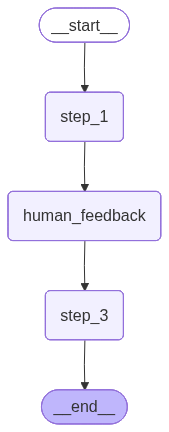

In [34]:
show_graph(graph)

In [35]:
# 输入
initial_input = {"input": "你好世界"}

# 线程
thread = {"configurable": {"thread_id": "1"}}

# 运行图直到第一次中断
for event in graph.stream(initial_input, thread, stream_mode="updates"):
    print(event)
    print("\n")

---步骤 1---
{'step_1': None}


---人工反馈---
{'__interrupt__': (Interrupt(value='请提供反馈：', resumable=True, ns=['human_feedback:054ea341-717a-fa78-78ee-2a4a68bca66f'], when='during'),)}




要从中断恢复，我们可以使用 [`Command` 对象](https://langchain-ai.github.io/langgraph/how-tos/command/)。

我们将使用它从中断状态恢复图，将值传递给 `resume` 以从中断调用返回。

In [36]:
# 继续图执行
for event in graph.stream(
    Command(resume="去步骤 3！"),
    thread,
    stream_mode="updates",
):
    print(event)
    print("\n")

---人工反馈---
{'human_feedback': {'user_feedback': '去步骤 3！'}}


---步骤 3---
{'step_3': None}




### 跟踪

当我们使用 LangChain 或 LangGraph 时，LangSmith 日志记录 [将开箱即用](https://docs.smith.langchain.com/observability/how_to_guides/trace_with_langgraph)，只需设置以下环境变量：

```
export LANGSMITH_TRACING=true
export LANGSMITH_API_KEY="<your-langsmith-api-key>"
```

这是上面智能体执行的 LangSmith 跟踪：

https://smith.langchain.com/public/6f77014f-d054-44ed-aa2c-8b06ceab689f/r

我们可以看到智能体能够从之前的状态继续对话，因为我们使用了检查点。

### 部署

我们也可以使用 [LangGraph Platform](https://langchain-ai.github.io/langgraph/concepts/langgraph_platform/) 部署我们的图。

这会创建一个 [带有 API](https://langchain-ai.github.io/langgraph/cloud/reference/api/api_ref.html) 的服务器，我们可以使用它与我们的图交互，以及一个交互式 IDE，LangGraph [Studio](https://langchain-ai.github.io/langgraph/concepts/langgraph_studio/)。

我们只需要确保我们的项目有 [这样的结构](https://langchain-ai.github.io/langgraph/concepts/application_structure/)：

```
my-app/
├── src/email_assistant # 所有项目代码都在这里
│   └── langgraph101.py # 构建图的代码
├── .env # 环境变量
├── langgraph.json  # LangGraph 的配置文件
└── pyproject.toml # 项目的依赖项
```

`langgraph.json` 文件指定启动 LangGraph 服务器所需的依赖项、图、环境变量和其他设置。

为了测试这个，让我们部署 `langgraph_101.py`。我们在这个仓库的 `langgraph.json` 文件中有它：

```
 "langgraph101": "./src/email_assistant/langgraph_101.py:app",
```

对于 LangGraph Platform，有一系列 [部署选项](https://langchain-ai.github.io/langgraph/tutorials/deployment/)：
 
* 本地部署可以从仓库的根目录用 `langgraph dev` 启动。检查点保存到本地文件系统。
* 还有各种 [自托管选项](https://langchain-ai.github.io/langgraph/tutorials/deployment/#other-deployment-options)。
* 对于托管部署，检查点使用 postgres [检查点](https://langchain-ai.github.io/langgraph/concepts/persistence/#checkpointer-libraries) 保存到 Postgres。

测试：
```
为我老板 (boss@company.ai) 起草一封回复，确认我想参加 Interrupt！
```

在这里我们可以看到图的可视化以及 Studio 中的图状态。

![langgraph_studio](img/langgraph_studio.png)

此外，您可以在这里看到本地部署的 API 文档：

http://127.0.0.1:2024/docs